In [74]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)


In [75]:
# download the data
df = pd.read_csv('../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv')
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time')
df = df.resample('d').sum()
y = df['bruehler_straße']
y = y.values.reshape(-1, 1)
df.head()

,bruehler_straße,estermannufer,kennedybruecke,nordbruecke,suedbruecke,rhenusallee,von_sandt_ufer,weg_auf_dem_damm,wilhelm_spiritus_ufer
time,,,,,,,,,
2016-01-16,256,50,2212,173,333,249,210,271,361
2016-01-17,164,59,1533,230,358,316,220,339,358
2016-01-18,559,145,5055,442,1633,783,566,792,1387
2016-01-19,581,151,6233,483,1658,770,586,743,1279
2016-01-20,513,141,5167,425,1543,668,505,612,1199


In [76]:
# scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(y)
y = scaler.transform(y)

In [77]:
# generate the input and output sequences
n_lookback = 28  # length of input sequences (lookback period)
n_forecast = 7 # length of output sequences (forecast period)

X = []
Y = []

for i in range(n_lookback, len(y) - n_forecast + 1):
    X.append(y[i - n_lookback: i])
    Y.append(y[i: i + n_forecast])

X = np.array(X)
Y = np.array(Y)

In [78]:
# fit the model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_lookback, 1)))
model.add(LSTM(units=50))
model.add(Dense(n_forecast))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
early = EarlyStopping(monitor='val_loss', patience=10)
check = ModelCheckpoint(filepath='bruehler_straße.keras', monitor='val_loss', save_best_only=True)
bruehl = model.fit(X, Y, batch_size=32, epochs=100, shuffle=True, validation_split = 0.1, callbacks=[early, check], verbose=1)

Epoch 1/100


/home/leonidas/Uni/Semester_5_24_25/Datenanalyse/Projekt/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0120 - mae: 0.0856 - val_loss: 0.0049 - val_mae: 0.0384
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0589 - val_loss: 0.0049 - val_mae: 0.0384
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0586 - val_loss: 0.0049 - val_mae: 0.0382
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0586 - val_loss: 0.0049 - val_mae: 0.0382
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0585 - val_loss: 0.0049 - val_mae: 0.0382
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051 - mae: 0.0583 - val_loss: 0.0049 - val_mae: 0.0381
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0050 - mae: 0.0582 - val_loss: 0.0049 - val_mae: 0.0381
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0050 - mae: 0.0581 - val_loss: 0.0049 - val_mae: 0.0379
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0050 - mae: 0.

In [79]:
# generate the forecasts
X_ = y[- n_lookback:]  # last available input sequence
X_ = X_.reshape(1, n_lookback, 1)

Y_ = model.predict(X_).reshape(-1, 1)
Y_ = scaler.inverse_transform(Y_)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


In [80]:
# organize the results in a data frame
df_past = df[['bruehler_straße']].reset_index()
df_past['time'] = pd.to_datetime(df_past['time'])
df_past['Forecast'] = np.nan
df_past['Forecast'].iloc[-1] = df_past['bruehler_straße'].iloc[-1]
df_past

/tmp/ipykernel_156348/3045946866.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_past['Forecast'].iloc[-1] = df_past['bruehler_straße'].iloc[-1]


,time,bruehler_straße,Forecast
0,2016-01-16,256,NaN
1,2016-01-17,164,NaN
2,2016-01-18,559,NaN
3,2016-01-19,581,NaN
4,2016-01-20,513,NaN
...,...,...,...
2902,2023-12-27,312,NaN
2903,2023-12-28,312,NaN
2904,2023-12-29,312,NaN
2905,2023-12-30,312,NaN


In [81]:
df_future = pd.DataFrame(columns=['time', 'bruehler_straße', 'Forecast'])
df_future['time'] = pd.date_range(start=df_past['time'].iloc[-1] + pd.Timedelta(hours=1), periods=n_forecast)
df_future['Forecast'] = Y_.flatten()
df_future['bruehler_straße'] = np.nan
df_future

,time,bruehler_straße,Forecast
0,2023-12-31 01:00:00,NaN,561.019775
1,2024-01-01 01:00:00,NaN,609.136780
2,2024-01-02 01:00:00,NaN,600.637817
3,2024-01-03 01:00:00,NaN,611.796448
4,2024-01-04 01:00:00,NaN,602.461365
5,2024-01-05 01:00:00,NaN,599.914612
6,2024-01-06 01:00:00,NaN,601.373840


In [82]:
#results = df_past.concat(df_future).set_index('Date')
results = pd.concat([df_past, df_future])
results = results.set_index('time')
results.head()

,bruehler_straße,Forecast
time,,
2016-01-16,256.0,NaN
2016-01-17,164.0,NaN
2016-01-18,559.0,NaN
2016-01-19,581.0,NaN
2016-01-20,513.0,NaN


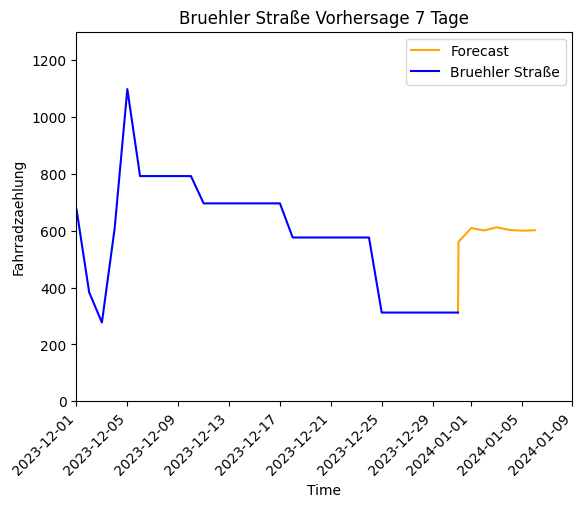

In [86]:
# plot the results
plt.plot(results['Forecast'], color = 'orange', label = 'Forecast')
plt.plot(results['bruehler_straße'], color = 'blue', label = 'Bruehler Straße')
plt.title('Bruehler Straße Vorhersage 7 Tage')
plt.xlabel('Time')
plt.ylabel('Fahrradzaehlung')
plt.legend()
start_date = datetime(2023, 12, 1)
end_date = datetime(2024, 1, 9)
plt.xlim(start_date, end_date)
plt.ylim(0,1300)
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0, 0.5, 'loss')

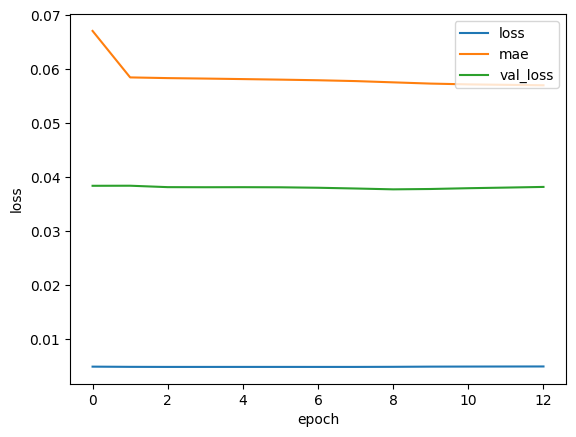

In [84]:
plt.plot(bruehl.history['val_loss'])
plt.plot(bruehl.history['mae'])
plt.plot(bruehl.history['val_mae'])
plt.legend(['loss', 'mae', 'val_loss', 'val_mae'])
plt.xlabel('epoch')
plt.ylabel('loss')

In [85]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 28, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,873 (362.79 KB)

 Trainable params: 30,957 (120.93 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,916 (241.86 KB)